# Lecture 1. Why this course exists

**Convex optimization, Fall 2026**

One sentence for the whole term:

> Convexity is the largest problem class where a local minimum is global **and** you can certify it.

Today is a tour, not a definitions dump. We will run three pictures that still pay rent in 2026, after a short notation sheet that the rest of the course will reuse. PDLP and Muon continue in lecture 2.


## Plan

0. Notation (vectors, inner products, gradients, norms, duals, the problem template)
1. $\ell_1$ magic — cardinality is NP-hard, a linear program often solves it (and a picture where it does not)
2. Goemans–Williamson MaxCut — an SDP plus a random hyperplane
3. How numerical methods work — oracles, rates, what a bound means — then Nesterov vs Adam

Lecture 2 continues the tour: PDLP (first-order LP on GPUs) and Muon (spectral-norm steepest descent).

Each section ends with **papers / surveys / tutorials** (clickable). Start there if you want the full statement of a claim we only ran as a picture.


In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
plt.rcParams.update(
    {
        "figure.figsize": (7.2, 4.0),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 11,
    }
)


# 0. Notation

We work in finite dimension. The same letters will mean the same things every week.


## 0.1 Vectors and matrices

| Object | Symbol | Lives in |
|---|---|---|
| Scalar | $\alpha,\beta,\lambda,\eta$ | $\mathbb{R}$ |
| Vector | $\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{c},\mathbf{g}$ | $\mathbb{R}^n$ |
| Matrix | $\mathbf{A},\mathbf{B},\mathbf{W}$ | $\mathbb{R}^{m\times n}$ |
| Symmetric matrix | $\mathbf{X},\mathbf{H},\mathbf{L}$ | $\mathbf{S}^n = \{\mathbf{X}\in\mathbb{R}^{n\times n}: \mathbf{X}=\mathbf{X}^\top\}$ |
| PSD cone | $\mathbf{X}\succeq 0$ | $\mathbf{S}^n_+ = \{\mathbf{X}\in\mathbf{S}^n: \mathbf{v}^\top \mathbf{X} \mathbf{v} \ge 0\ \forall \mathbf{v}\}$ |

- All vectors are columns, and **vectors and matrices are bold**.
- The $i$-th entry of $\mathbf{x}$ is $x_i$
- The $(i,j)$-th entry of $\mathbf{A}$ is $A_{ij}$.
- The all-ones vector is $\mathbf{1}$.
- The standard basis is $\mathbf{e}_1,\ldots,\mathbf{e}_n$.


## 0.2 Inner products

On vectors
$$
\langle \mathbf{x}, \mathbf{y}\rangle = \mathbf{x}^\top \mathbf{y} = \sum_{i=1}^n \mathbf{x}_i \mathbf{y}_i.
$$

On matrices (Frobenius inner product)
$$
\langle \mathbf{A}, \mathbf{B}\rangle = \mathrm{tr}(\mathbf{A}^\top \mathbf{B}) = \sum_{ij} \mathbf{A}_{ij} \mathbf{B}_{ij}.
$$

Both are Euclidean inner products after stacking entries. A gradient is the unique vector (or matrix) that represents the first-order increment of $f$ in this inner product. That is the next three slides.


### Differentiable functions

- A function $f:\mathbb{R}^n\to\mathbb{R}$ is **differentiable** at $\mathbf{x}$ if there exists a vector $f'(\mathbf{x})\in\mathbb{R}^n$ such that
$$
f(\mathbf{x}+\boldsymbol{\delta}) = f(\mathbf{x}) + \langle f'(\mathbf{x}), \boldsymbol{\delta}\rangle + o(\|\boldsymbol{\delta}\|)
\qquad\text{as }\|\boldsymbol{\delta}\|\to 0.
$$
The little-o means the remainder divided by $\|\boldsymbol{\delta}\|$ goes to $0$. 
- The vector $f'(\mathbf{x})$ is the **gradient**. 
- It is unique: if two vectors both work, their difference is orthogonal to every $\boldsymbol{\delta}$, hence zero.

- The same definition on matrices, with the Frobenius inner product: $f:\mathbb{R}^{m\times n}\to\mathbb{R}$ is differentiable at $\mathbf{W}$ if there is a matrix $f'(\mathbf{W})$ of the same shape with
$$
f(\mathbf{W}+\boldsymbol{\Delta}) = f(\mathbf{W}) + \langle f'(\mathbf{W}), \boldsymbol{\Delta}\rangle + o(\|\boldsymbol{\Delta}\|_F).
$$
- In this course almost every $f$ is $C^1$ (partials exist and are continuous), which implies differentiability. We will not distinguish the two.


### How to compute a gradient

Three equivalent recipes. Use whichever makes the algebra shortest.

**1. Elementwise.** Write the partial derivatives and stack them:
$$
\bigl(f'(\mathbf{x})\bigr)_i = \frac{\partial f}{\partial x_i},
\qquad
\bigl(f'(\mathbf{X})\bigr)_{ij} = \frac{\partial f}{\partial X_{ij}}.
$$
- This is the coordinate definition. 
- It is the right tool when $f$ is a short formula in the entries, and the wrong tool for $\det$, $\log\det$, or eigenvalues.

**2. Linearization.** Expand $f(\mathbf{x}+\boldsymbol{\delta})$ to the first order, drop $o(\|\boldsymbol{\delta}\|)$, and match
$$
\text{linear term in }\boldsymbol{\delta} = \langle \mathbf{g}, \boldsymbol{\delta}\rangle.
$$
Then $\mathbf{g}=f'(\mathbf{x})$.

**3. Differential.** Same expansion, different notation:
$$
\mathrm{d}f = \langle f'(\mathbf{x}), \mathrm{d}\mathbf{x}\rangle.
$$
The usual calculus rules hold: 
- $\mathrm{d}(\alpha f+\beta g)=\alpha\,\mathrm{d}f+\beta\,\mathrm{d}g$,
- product rule
- chain rule. 

Matrix identities become short, e.g. 
- $\mathrm{d}\,\mathrm{tr}(\mathbf{A}^\top \mathbf{X})=\langle \mathbf{A},\mathrm{d}\mathbf{X}\rangle$
- $\mathrm{d}(\mathbf{X}^{-1})=-\mathbf{X}^{-1}(\mathrm{d}\mathbf{X})\mathbf{X}^{-1}$.


### Example: gradient of the determinant

Let $f(\mathbf{X})=\det(\mathbf{X})$ on $\mathbb{R}^{n\times n}$. This is a polynomial in the entries, hence differentiable everywhere.

**Elementwise.** 
- Laplace expansion: $\partial\det/\partial \mathbf{X}_{ij}$ is the $(i,j)$ cofactor $C_{ij}$. 
- So $f'(\mathbf{X})=\mathrm{cof}(\mathbf{X})$. 
- If $\mathbf{X}$ is invertible, $\mathrm{cof}(\mathbf{X})=\det(\mathbf{X})\,\mathbf{X}^{-\top}$.

**Linearization** 
For invertible $\mathbf{X}$,
$$
\det(\mathbf{X}+\boldsymbol{\Delta})=\det\bigl(\mathbf{X}(\mathbf{I}+\mathbf{X}^{-1}\boldsymbol{\Delta})\bigr)=\det(\mathbf{X})\,\det(\mathbf{I}+\mathbf{X}^{-1}\boldsymbol{\Delta}).
$$
- The scalar expansion $\det(\mathbf{I}+\mathbf{E})=1+\mathrm{tr}(\mathbf{E})+o(\|\mathbf{E}\|)$ (next slide) gives
$$
\det(\mathbf{X}+\boldsymbol{\Delta})=\det(\mathbf{X})+\det(\mathbf{X})\,\mathrm{tr}(\mathbf{X}^{-1}\boldsymbol{\Delta})+o(\|\boldsymbol{\Delta}\|).
$$
- The linear term is $\langle \det(\mathbf{X})\,\mathbf{X}^{-\top},\,\boldsymbol{\Delta}\rangle$, therefore
$$
f'(\mathbf{X})=\det(\mathbf{X})\,\mathbf{X}^{-\top}.
$$

Cookbook: Petersen and Pedersen, [*The Matrix Cookbook*](https://www.math.uwaterloo.ca/~hwolkowi/matrixcookbook.pdf)


### Why $\det(\mathbf{I}+\mathbf{E})=1+\mathrm{tr}(\mathbf{E})+o(\|\mathbf{E}\|)$

- Assume that $\mathbf{E}$ is symmetric
- $\det(z\mathbf{I}-\mathbf{E})=\prod_{i=1}^n(z-\lambda_i)$ is the definition of the $\lambda_i$.

- The eigenvalues of $\mathbf{I}+\mathbf{E}$ are $1+\lambda_i(\mathbf{E})$, because
$$
\det\bigl(z\mathbf{I}-(\mathbf{I}+\mathbf{E})\bigr)=\det\bigl((z-1)\mathbf{I}-\mathbf{E}\bigr)=\prod_{i=1}^n\bigl(z-1-\lambda_i\bigr).
$$
- The determinant is the product of the eigenvalues and the trace is their sum, so
$$
\det(\mathbf{I}+\mathbf{E})=\prod_{i=1}^n(1+\lambda_i),\qquad \mathrm{tr}(\mathbf{E})=\sum_{i=1}^n\lambda_i.
$$
- Expand the product:
$$
\prod_{i=1}^n(1+\lambda_i)=1+\sum_{i=1}^n\lambda_i+\sum_{k=2}^n e_k(\lambda_1,\ldots,\lambda_n)=1+\mathrm{tr}(\mathbf{E})+\text{(degree $\ge 2$)}.
$$
- The spectral radius is at most any matrix norm, $|\lambda_i|\le\|\mathbf{E}\|$, so every elementary symmetric polynomial $e_k$ of degree $k\ge 2$ is $O(\|\mathbf{E}\|^k)=O(\|\mathbf{E}\|^2)$. Therefore
$$
\det(\mathbf{I}+\mathbf{E})=1+\mathrm{tr}(\mathbf{E})+O(\|\mathbf{E}\|^2).
$$


In [6]:
# Finite-difference check: <f'(X), dX> vs (det(X+t dX)-det(X))/t
n = 5
X = rng.normal(size=(n, n))
X = X + n * np.eye(n)  # invertible
dX = rng.normal(size=(n, n))
grad = np.linalg.det(X) * np.linalg.inv(X).T
t = 1e-6
fd = (np.linalg.det(X + t * dX) - np.linalg.det(X)) / t
lin = float(np.sum(grad * dX))
print(f"finite difference  {fd:.6e}")
print(f"Frobenius pairing  {lin:.6e}")
print(f"relative error     {abs(fd - lin) / abs(fd):.2e}")


finite difference  1.476217e+03
Frobenius pairing  1.476217e+03
relative error     4.64e-07


## 0.3 Norms

A norm $\|\cdot\|$ is nonnegative, absolutely homogeneous, and satisfies the triangle inequality. The ones we will actually use:

$$
\|\mathbf{x}\|_2 = \sqrt{\langle \mathbf{x},\mathbf{x}\rangle},\qquad
\|\mathbf{x}\|_1 = \sum_i |\mathbf{x}_i|,\qquad
\|\mathbf{x}\|_\infty = \max_i |\mathbf{x}_i|,
$$

$$
\|\mathbf{A}\|_F = \sqrt{\langle \mathbf{A},\mathbf{A}\rangle},\qquad
\|\mathbf{A}\|_{2\to 2} = \sigma_{\max}(\mathbf{A})\quad \text{(spectral / operator norm)},
$$

$$
\|\mathbf{A}\|_* = \sum_i \sigma_i(\mathbf{A})\quad \text{(nuclear norm)}.
$$

The Euclidean ball, the $\ell_1$ ball, and the nuclear-norm ball are three different convex sets that encode three different notions of “small”.


## 0.4 Dual norms

Given a norm $\|\cdot\|$ on a space, its dual is
$$
\|\mathbf{z}\|_* = \sup_{\|\mathbf{x}\|\le 1} \langle \mathbf{z}, \mathbf{x}\rangle.
$$

Standard pairs (do not confuse the dual-norm subscript with the nuclear norm):

| Primal | Dual |
|---|---|
| $\|\mathbf{x}\|_p$ | $\|\mathbf{z}\|_q$ with $\tfrac1p+\tfrac1q=1$ |
| $\|\mathbf{x}\|_2$ | $\|\mathbf{z}\|_2$ |
| $\|\mathbf{x}\|_1$ | $\|\mathbf{z}\|_\infty$ |
| $\|\mathbf{A}\|_{2\to 2}$ | $\|\mathbf{B}\|_*$ |
| $\|\mathbf{A}\|_*$ | $\|\mathbf{B}\|_{2\to 2}$ |

Steepest descent of $f$ in the norm $\|\cdot\|$ is
$$
\mathbf{x}^+ = \mathbf{x} - \eta\cdot \arg\max_{\|\mathbf{v}\|\le 1} \langle f'(\mathbf{x}), \mathbf{v}\rangle,
$$
i.e. a linear maximization over the unit ball of the **primal** norm, which is exactly the definition of the dual norm. Euclidean GD is the special case $\|\cdot\|_2$. Muon, next lecture, is the special case $\|\cdot\|_{2\to 2}$ on matrices.


## 0.5 Convex sets and functions (definitions only)

A set $C\subseteq\mathbb{R}^n$ is **convex** if
$$
\mathbf{x},\mathbf{y}\in C,\ \theta\in[0,1]\quad\Rightarrow\quad \theta \mathbf{x}+(1-\theta)\mathbf{y}\in C.
$$

A function $f:\mathbb{R}^n\to\mathbb{R}\cup\{+\infty\}$ is **convex** if its epigraph
$\mathrm{epi}\,f = \{(\mathbf{x},t): f(\mathbf{x})\le t\}$ is a convex set, equivalently
$$
f(\theta \mathbf{x}+(1-\theta)\mathbf{y})\le \theta f(\mathbf{x})+(1-\theta)f(\mathbf{y})
$$
for all $\mathbf{x},\mathbf{y}$ and $\theta\in[0,1]$ (with the usual arithmetic of $+\infty$).

Sets we will meet constantly: 
- the simplex $\Delta^{n-1}=\{\mathbf{x}\ge 0:\mathbf{1}^\top \mathbf{x}=1\}$,
- the $\ell_1$ ball
- the PSD cone $\mathbf{S}^n_+$
- the spectrahedron $\{\mathbf{X}\succeq 0:\mathrm{diag}(\mathbf{X})=\mathbf{1}\}$.

**Fact we will use all term, and not prove today:** on a convex function over a convex set, every local minimizer is global. 

If the problem is convex and constraint qualifications hold, KKT conditions are necessary *and* sufficient — they are a certificate.


## 0.6 The problem template

$$
\begin{array}{ll}
\text{minimize}  & f_0(\mathbf{x}) \\
\text{subject to}& f_i(\mathbf{x})\le 0,\quad i=1,\ldots,m,\\
                 & \mathbf{A}\mathbf{x}=\mathbf{b}.
\end{array}
$$

- Optimal value $p^\star$, a minimizer $\mathbf{x}^\star\in\arg\min f_0$ (if one exists).
- We will write LPs, QPs, SOCPs, SDPs as special cases of this template
- First-order methods as algorithms that only query $f_0$ and $f'_0$ (and maybe a projection onto the feasible set).



### References — notation and the course backbone

- **Book.** S. Boyd and L. Vandenberghe, [*Convex Optimization*](https://web.stanford.edu/~boyd/cvxbook/) (CUP, 2004). Free PDF; this is the default language of the course (Ch. 2–5 for sets/functions/problems, App. A for norms and duals).
- **Book.** Y. Nesterov, [*Lectures on Convex Optimization*](https://doi.org/10.1007/978-3-319-91578-4) (Springer, 2018). Complexity, first-order methods, self-concordance.
- **Survey.** S. Bubeck, [*Convex Optimization: Algorithms and Complexity*](https://arxiv.org/abs/1405.4980), *Found. Trends ML*, 2015.
- **Lectures.** [EE364a](https://web.stanford.edu/class/ee364a/) (slides + CVXPY); A. Nemirovski, [*Lectures on Modern Convex Optimization*](https://www2.isye.gatech.edu/~nemirovs/Lect_EMCO.pdf).
- **Tutorial / software.** [CVXPY tutorial](https://www.cvxpy.org/tutorial/intro/index.html); S. Diamond and S. Boyd, [*CVXPY: A Python-embedded modeling language for convex optimization*](https://arxiv.org/abs/1603.00943); M. Grant, S. Boyd, Y. Ye, [*Disciplined convex programming*](https://web.stanford.edu/~boyd/papers/pdf/disc_cvx_prog.pdf).



# 1. $\ell_1$ magic

- Finding the sparsest solution of $\mathbf{A}\mathbf{x}=\mathbf{y}$ is NP-hard (cardinality, $\ell_0$). 
- Replacing $\#\{i:\mathbf{x}_i\neq 0\}$ by $\|\mathbf{x}\|_1$ is a linear program. 
- For many underdetermined $\mathbf{A}$, that LP returns the *exact* sparse vector. 
- It is still a *proxy*: the second picture is a kernel where the unique $\ell_1$ minimizer is dense, while a 1-sparse feasible $\mathbf{x}$ sits in the same affine space.

$$
\min_{\mathbf{x}}\ \|\mathbf{x}\|_0 \quad\text{s.t.}\ \mathbf{A}\mathbf{x}=\mathbf{y}
\qquad\longrightarrow\qquad
\min_{\mathbf{x}}\ \|\mathbf{x}\|_1 \quad\text{s.t.}\ \mathbf{A}\mathbf{x}=\mathbf{y}
\quad\text{(basis pursuit).}
$$

- The $\ell_2$ cousin 
$$
\min\|\mathbf{x}\|_2 \quad \text{s.t. } \quad \mathbf{A}\mathbf{x}=\mathbf{y}
$$
 is the pseudoinverse. It spreads mass over all coordinates and almost never recovers spikes.

- This is the same convex-envelope idea as lasso, basis pursuit denoising, and the inner sparse-coding / SAE step you will see later in the course.


m, n, sparsity = 30, 80, 4
least squares  ||x - x_true||_2 = 1.512e+00
basis pursuit  ||x - x_true||_2 = 2.182e-10
BP entries with |x_i| > 1e-4: 4


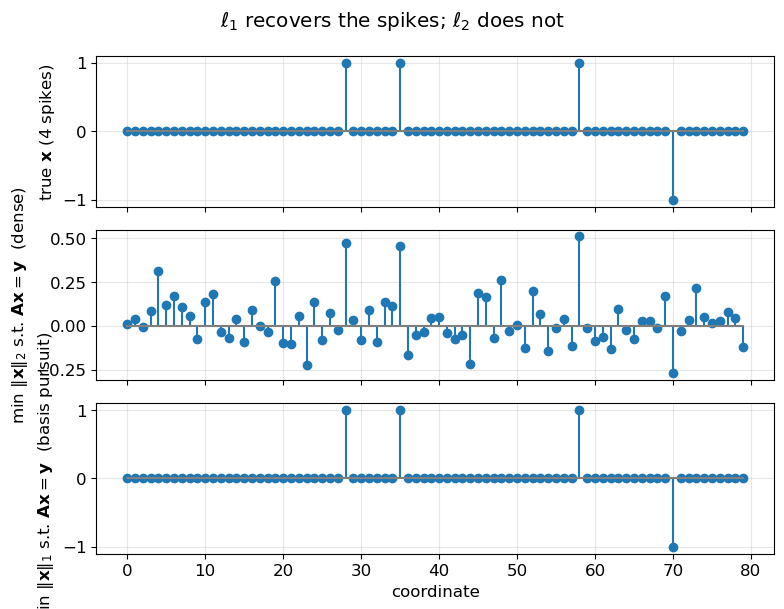

In [3]:
n, m, s = 80, 30, 4
A = rng.normal(size=(m, n)) / np.sqrt(m)
x_true = np.zeros(n)
support = rng.choice(n, size=s, replace=False)
x_true[support] = rng.choice([-1.0, 1.0], size=s)
y = A @ x_true  # noiseless, m << n

x_ls = np.linalg.lstsq(A, y, rcond=None)[0]

x_bp = cp.Variable(n)
bp = cp.Problem(cp.Minimize(cp.norm1(x_bp)), [A @ x_bp == y])
bp.solve(solver=cp.CLARABEL)
x_bp = np.asarray(x_bp.value).ravel()

print(f"m, n, sparsity = {m}, {n}, {s}")
print(f"least squares  ||x - x_true||_2 = {np.linalg.norm(x_ls - x_true):.3e}")
print(f"basis pursuit  ||x - x_true||_2 = {np.linalg.norm(x_bp - x_true):.3e}")
print(f"BP entries with |x_i| > 1e-4: {int(np.sum(np.abs(x_bp) > 1e-4))}")

fig, axes = plt.subplots(3, 1, figsize=(8.0, 6.2), sharex=True)
for ax, x, title in [
    (axes[0], x_true, r"true $\mathbf{x}$ (4 spikes)"),
    (axes[1], x_ls, r"min $\|\mathbf{x}\|_2$ s.t. $\mathbf{A}\mathbf{x}=\mathbf{y}$  (dense)"),
    (axes[2], x_bp, r"min $\|\mathbf{x}\|_1$ s.t. $\mathbf{A}\mathbf{x}=\mathbf{y}$  (basis pursuit)"),
]:
    ax.stem(np.arange(n), x, basefmt="C7-")
    ax.set_ylabel(title)
axes[-1].set_xlabel("coordinate")
fig.suptitle(r"$\ell_1$ recovers the spikes; $\ell_2$ does not")
fig.tight_layout()
plt.show()


- The **null space property** of order 1 fails if some $\mathbf{v}\in\ker(\mathbf{A})$ puts at least as much $\ell_1$ mass on one coordinate as on the rest, $|\mathbf{v}_i|\ge\|\mathbf{v}_{-i}\|_1$.
- Then a 1-sparse $\mathbf{x}$ and a dense $\mathbf{x}+t\mathbf{v}$ share the same $\mathbf{A}\mathbf{x}$, and $\ell_1$ prefers the dense one.

- Take $\ker(\mathbf{A})=\mathrm{span}\{\mathbf{v}\}$ with $\mathbf{v}=\bigl(2,-\tfrac{1}{n-1},\ldots,-\tfrac{1}{n-1}\bigr)$ and $\mathbf{x}^\star=\mathbf{e}_1$.
- Along the line $\mathbf{x}^\star+t\mathbf{v}$ the unique $\ell_1$ minimizer is at $t=-\tfrac12$: one zero and $n-1$ equal nonzeros, with $\|\mathbf{x}\|_1=\tfrac12<\|\mathbf{x}^\star\|_1=1$.
- Clarabel solver finds that dense vector.
- This is not a solver bug — the LP is doing its job.

ker(A) = span(v),  |v_1| = 2,  ||v[1:]||_1 = 1
1-sparse feasible   l0 = 1,  l1 = 1.000
basis pursuit       l0 = 7,  l1 = 0.500
||A x_bp - y||_2 = 2.9e-16   (same measurements)


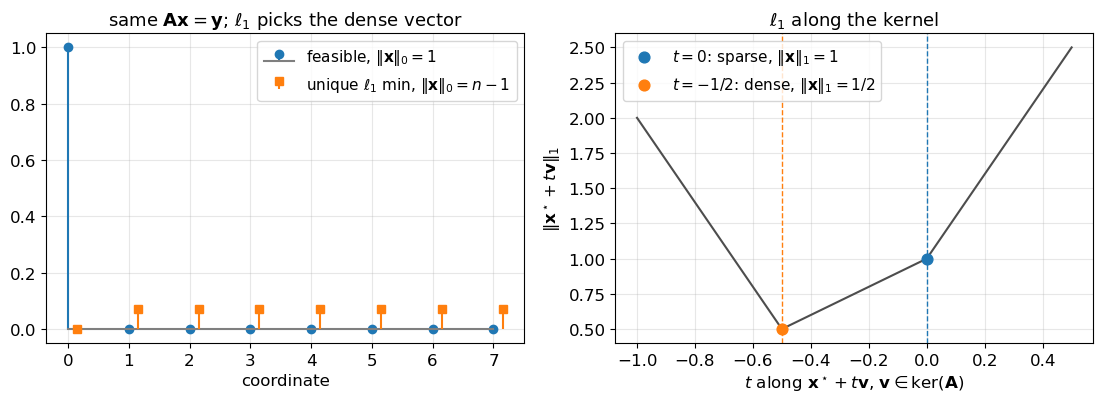

In [4]:
n_fail = 8
v = np.concatenate([[2.0], -np.ones(n_fail - 1) / (n_fail - 1)])
A_fail = np.column_stack([v[1:], -v[0] * np.eye(n_fail - 1)])  # Av = 0
x_sparse = np.zeros(n_fail)
x_sparse[0] = 1.0
y_fail = A_fail @ x_sparse

x_bp_fail = cp.Variable(n_fail)
bp_fail = cp.Problem(cp.Minimize(cp.norm1(x_bp_fail)), [A_fail @ x_bp_fail == y_fail])
bp_fail.solve(solver=cp.CLARABEL)
x_bp_fail = np.asarray(x_bp_fail.value).ravel()

print(f"ker(A) = span(v),  |v_1| = {abs(v[0]):.0f},  ||v[1:]||_1 = {np.sum(np.abs(v[1:])):.0f}")
print(f"1-sparse feasible   l0 = {int(np.sum(np.abs(x_sparse) > 1e-8))},  l1 = {np.sum(np.abs(x_sparse)):.3f}")
print(f"basis pursuit       l0 = {int(np.sum(np.abs(x_bp_fail) > 1e-6))},  l1 = {np.sum(np.abs(x_bp_fail)):.3f}")
print(f"||A x_bp - y||_2 = {np.linalg.norm(A_fail @ x_bp_fail - y_fail):.1e}   (same measurements)")

ts = np.linspace(-1.0, 0.5, 400)
l1_path = np.array([np.sum(np.abs(x_sparse + t * v)) for t in ts])

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
axes[0].stem(np.arange(n_fail), x_sparse, linefmt="C0-", markerfmt="C0o", basefmt="C7-", label=r"feasible, $\|\mathbf{x}\|_0=1$")
axes[0].stem(np.arange(n_fail) + 0.15, x_bp_fail, linefmt="C1-", markerfmt="C1s", basefmt=" ", label=r"unique $\ell_1$ min, $\|\mathbf{x}\|_0=n-1$")
axes[0].set_xlabel("coordinate")
axes[0].set_title(r"same $\mathbf{A}\mathbf{x}=\mathbf{y}$; $\ell_1$ picks the dense vector")
axes[0].legend()

axes[1].plot(ts, l1_path, color="0.3")
axes[1].scatter([0.0], [1.0], s=60, zorder=3, label=r"$t=0$: sparse, $\|\mathbf{x}\|_1=1$")
axes[1].scatter([-0.5], [0.5], s=60, zorder=3, label=r"$t=-1/2$: dense, $\|\mathbf{x}\|_1=1/2$")
axes[1].axvline(0.0, color="C0", ls="--", lw=1)
axes[1].axvline(-0.5, color="C1", ls="--", lw=1)
axes[1].set_xlabel(r"$t$ along $\mathbf{x}^\star + t\mathbf{v}$, $\mathbf{v}\in\ker(\mathbf{A})$")
axes[1].set_ylabel(r"$\|\mathbf{x}^\star+t\mathbf{v}\|_1$")
axes[1].set_title(r"$\ell_1$ along the kernel")
axes[1].legend(loc="upper left")
fig.tight_layout()
plt.show()

### Takeaway 

- The feasible set $\{\mathbf{x}:\mathbf{A}\mathbf{x}=\mathbf{y}\}$ is an affine subspace (convex). 
- Among all explanations of $\mathbf{y}$, 
    - $\ell_2$ picks the shortest Euclidean vector;
    - $\ell_1$ picks a point of smallest $\ell_1$ mass. 
- Vertices of the $\ell_1$ ball are sparse, so when the affine space first hits a vertex you get spikes. 
- It can miss them: if a kernel vector violates **the null space property**, a dense point on the same affine space has *strictly smaller* $\ell_1$ than a 1-sparse feasible $\mathbf{x}$, and the LP will return the dense one. 
- Candès–Romberg–Tao / Donoho (~2006): if $\mathbf{A}$ is incoherent / RIP and $\mathbf{x}$ is sparse enough, this cannot happen and basis pursuit is *exact*.



### RIP property 

- Matrix $\mathbf{A}$ satisfies the *restricted isometry property* of order $s$ with constant $\delta_s\in(0,1)$ if
$$
(1-\delta_s)\|\mathbf{x}\|_2^2\le\|\mathbf{A}\mathbf{x}\|_2^2\le(1+\delta_s)\|\mathbf{x}\|_2^2
$$
for every $s$-sparse $\mathbf{x}$ — equivalently, every set of $s$ columns of $\mathbf{A}$ is nearly orthonormal. 
- If $\delta_{2s}$ is small enough (classically $\delta_{2s}<\sqrt{2}-1$), every $s$-sparse $\mathbf{x}$ is the unique $\ell_1$ minimizer of $\mathbf{A}\mathbf{x}=\mathbf{y}$.



### How you solve it 

- Basis pursuit is an LP, not a nonsmooth black box:
$$
\min_{\mathbf{x},\mathbf{t}}\ \mathbf{1}^\top \mathbf{t} \quad\text{s.t.}\ \mathbf{A}\mathbf{x}=\mathbf{y},\quad -\mathbf{t}\le \mathbf{x}\le \mathbf{t}.
$$
- Interior-point methods (Clarabel, the original $\ell_1$-magic codes) or simplex while factoring $\mathbf{A}$ is cheap — that is the call you just ran. At scale, do not factor. 
- The proximal map of $\|\cdot\|_1$ is coordinate-wise **soft-thresholding**
$$
\bigl(\mathrm{prox}_{\lambda\|\cdot\|_1}(\mathbf{z})\bigr)_i=\mathrm{sign}(\mathbf{z}_i)\max(|\mathbf{z}_i|-\lambda,0),
$$
so ISTA/FISTA (proximal gradient) and ADMM cost a matvec with $\mathbf{A}$, one with $\mathbf{A}^\top$, and a clip. 
- The same primal–dual saddle as PDLP (lecture 2) applies as well. 
- Subgradient descent on $\|\mathbf{x}\|_1$ is the method you should *not* use.




### References — $\ell_1$ and compressed sensing

- **Papers.** E. Candès, J. Romberg, T. Tao, [*Robust uncertainty principles: exact signal reconstruction from highly incomplete frequency information*](https://arxiv.org/abs/math/0409186), *IEEE TIT* 2006; E. Candès and T. Tao, [*Decoding by linear programming*](https://arxiv.org/abs/math/0502327), *IEEE TIT* 2005; D. Donoho, [*Compressed sensing*](https://doi.org/10.1109/TIT.2006.871582), *IEEE TIT* 2006.
- **When $\ell_1\neq\ell_0$.** A. Cohen, W. Dahmen, R. DeVore, [*Compressed sensing and best $k$-term approximation*](https://doi.org/10.1090/S0894-0347-08-00610-3), *J. Amer. Math. Soc.* 2009 (null space property).
- **Algorithms.** A. Beck and M. Teboulle, [*A fast iterative shrinkage-thresholding algorithm for linear inverse problems*](https://doi.org/10.1137/080716542) (FISTA), *SIAM J. Imaging Sci.* 2009; S. Boyd et al., [*Distributed optimization and statistical learning via the alternating direction method of multipliers*](https://doi.org/10.1561/2200000016), *Found. Trends ML* 2011. ℓ1-magic is a log-barrier interior-point method.
- **Tutorial.** E. Candès and M. Wakin, [*An introduction to compressive sampling*](https://authors.library.caltech.edu/26501/1/IEEESP08.pdf), *IEEE Signal Processing Magazine* 2008; software: [$\ell_1$-magic](https://candes.su.domains/software/l1magic/).
- **Book / survey.** S. Foucart and H. Rauhut, *A Mathematical Introduction to Compressive Sensing* (Birkhäuser, 2013); M. Elad, *Sparse and Redundant Representations* (Springer, 2010).


# 2. Goemans–Williamson MaxCut

- MaxCut is NP-hard. 
- Approach:
    - Lift the combinatorial $\pm 1$ vectors to a matrix $\mathbf{X}=\mathbf{x}\mathbf{x}^\top$ on the **spectrahedron**
    - drop $\mathrm{rank}(\mathbf{X})=1$
    - solve an SDP, round with a random hyperplane. 
- Approximation ratio $0.878$ — still essentially **the best** polynomial-time guarantee.

For an undirected graph with adjacency $\mathbf{W}$ and Laplacian $\mathbf{L}=\mathrm{diag}(\mathbf{W}\mathbf{1})-\mathbf{W}$,
$$
\mathrm{MaxCut} = \max_{\mathbf{x}\in\{\pm 1\}^n}\ \tfrac14 \mathbf{x}^\top \mathbf{L} \mathbf{x}.
$$
The SDP relaxation (Goemans–Williamson 1995) is
$$
\begin{array}{ll}
\text{maximize}  & \tfrac14 \langle \mathbf{L}, \mathbf{X}\rangle \\
\text{subject to}& X_{ii}=1,\quad i=1,\ldots,n,\\
                 & \mathbf{X}\succeq 0.
\end{array}
$$

- If $\mathbf{X}^\star = \mathbf{V}\mathbf{V}^\top$, draw $\mathbf{g}\sim\mathcal{N}(0,\mathbf{I})$ with normalization and set $\hat{\mathbf{x}} = \mathrm{sign}(\mathbf{V}\mathbf{g})$.
- Each pair of vertices is cut with probability $\arccos(\mathbf{X}_{ij})/\pi$.
- The guarantee $\alpha_{\mathrm{GW}}\approx 0.878$ is *worst-case*.
- Below we sample many `networkx` graphs (Erdős–Rényi, random regular, Barabási–Albert, Watts–Strogatz, odd cycles, bipartite), brute-force the integer cut at $n=12$, and compare it to the SDP certificate.


C5:  integer MaxCut = 4.0,  SDP = 4.5225,  integer/SDP = 0.884  (α_GW ≈ 0.878)


79 graphs, n ≤ 12  |  GW matched integer on 100% of instances
  Erdős–Rényi          29 graphs   integer/SDP  min 0.930  median 0.974
  3-regular            12 graphs   integer/SDP  min 0.966  median 0.990
  Barabási–Albert      12 graphs   integer/SDP  min 0.919  median 0.965
  Watts–Strogatz       12 graphs   integer/SDP  min 0.947  median 0.974
  bipartite             9 graphs   integer/SDP  min 1.000  median 1.000
  odd cycle             4 graphs   integer/SDP  min 0.884  median 0.909
  Petersen              1 graphs   integer/SDP  min 0.960  median 0.960


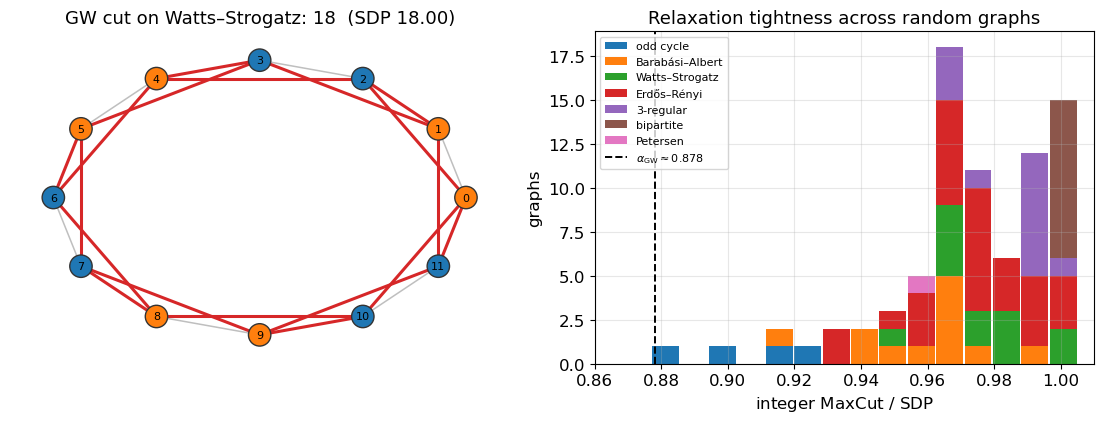

In [5]:
import networkx as nx

n_mc = 12
alpha_gw = 0.878

def graph_laplacian(G):
    W = nx.to_numpy_array(G, dtype=float)
    return np.diag(W.sum(axis=1)) - W


def maxcut_sdp(L):
    n = L.shape[0]
    X = cp.Variable((n, n), PSD=True)
    prob = cp.Problem(cp.Maximize(0.25 * cp.trace(L @ X)), [cp.diag(X) == 1])
    prob.solve(solver=cp.CLARABEL, verbose=False)
    Xv = 0.5 * (np.asarray(X.value) + np.asarray(X.value).T)
    return float(prob.value), Xv


def maxcut_integer(L):
    n = L.shape[0]
    bits = (np.arange(1 << (n - 1))[:, None] >> np.arange(n - 1)) & 1
    Xpm = np.concatenate([2.0 * bits - 1.0, np.ones((bits.shape[0], 1))], axis=1)
    return float(np.max(0.25 * np.einsum("bi,ij,bj->b", Xpm, L, Xpm)))


def gw_round(X_star, L, n_round=80):
    evals, evecs = np.linalg.eigh(X_star)
    V = evecs * np.sqrt(np.clip(evals, 0.0, None))
    Gmat = rng.normal(size=(n_round, L.shape[0]))
    Xh = np.sign(Gmat @ V.T)
    Xh[Xh == 0] = 1.0
    vals = 0.25 * np.einsum("bi,ij,bj->b", Xh, L, Xh)
    k = int(np.argmax(vals))
    return float(vals[k]), Xh[k]


def make_graphs(n):
    graphs = []
    for p in (0.2, 0.4, 0.6):
        for seed in range(10):
            G = nx.erdos_renyi_graph(n, p, seed=100 * int(10 * p) + seed)
            if G.number_of_edges() >= n:
                graphs.append(("Erdős–Rényi", G))
    for seed in range(12):
        graphs.append(("3-regular", nx.random_regular_graph(3, n, seed=seed)))
    for seed in range(12):
        graphs.append(("Barabási–Albert", nx.barabasi_albert_graph(n, 2, seed=seed)))
    for seed in range(12):
        graphs.append(("Watts–Strogatz", nx.watts_strogatz_graph(n, 4, 0.2, seed=seed)))
    for seed in range(8):
        G = nx.bipartite.random_graph(n // 2, n - n // 2, 0.45, seed=seed)
        if G.number_of_edges() > 0:
            graphs.append(("bipartite", G))
    graphs.append(("bipartite", nx.complete_bipartite_graph(n // 2, n - n // 2)))
    for k in range(5, n + 1, 2):
        graphs.append(("odd cycle", nx.cycle_graph(k)))
    graphs.append(("Petersen", nx.petersen_graph()))
    return graphs


L5 = graph_laplacian(nx.cycle_graph(5))
sdp5, _ = maxcut_sdp(L5)
opt5 = maxcut_integer(L5)
print(f"C5:  integer MaxCut = {opt5:.1f},  SDP = {sdp5:.4f},  integer/SDP = {opt5 / sdp5:.3f}  (α_GW ≈ {alpha_gw})")

graphs = make_graphs(n_mc)
families, ratios_opt, ratios_gw = [], [], []
show_G = show_x = show_val = show_sdp = None
for fam, G in graphs:
    L = graph_laplacian(G)
    sdp_val, X_star = maxcut_sdp(L)
    opt_val = maxcut_integer(L)
    gw_val, x_hat = gw_round(X_star, L)
    families.append(fam)
    ratios_opt.append(opt_val / sdp_val)
    ratios_gw.append(gw_val / sdp_val)
    if fam == "Watts–Strogatz" and show_G is None:
        show_G, show_x, show_val, show_sdp = G, x_hat, gw_val, sdp_val

families = np.array(families)
ratios_opt, ratios_gw = np.array(ratios_opt), np.array(ratios_gw)
print(
    f"{len(graphs)} graphs, n ≤ {n_mc}  |  "
    f"GW matched integer on {np.mean(np.isclose(ratios_gw, ratios_opt)):.0%} of instances"
)
for fam in dict.fromkeys(families):
    r = ratios_opt[families == fam]
    print(f"  {fam:18s}  {len(r):3d} graphs   integer/SDP  min {r.min():.3f}  median {np.median(r):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4))
pos = nx.circular_layout(show_G)
side = ["C0" if xi > 0 else "C1" for xi in show_x]
cut_e = [(u, v) for u, v in show_G.edges() if show_x[u] * show_x[v] < 0]
stay_e = [(u, v) for u, v in show_G.edges() if show_x[u] * show_x[v] > 0]
nx.draw_networkx_nodes(show_G, pos, ax=axes[0], node_color=side, node_size=260, edgecolors="0.2")
nx.draw_networkx_edges(show_G, pos, ax=axes[0], edgelist=stay_e, edge_color="0.75", width=1.1)
nx.draw_networkx_edges(show_G, pos, ax=axes[0], edgelist=cut_e, edge_color="C3", width=2.2)
nx.draw_networkx_labels(show_G, pos, ax=axes[0], font_size=8)
axes[0].set_title(f"GW cut on Watts–Strogatz: {show_val:.0f}  (SDP {show_sdp:.2f})")
axes[0].set_axis_off()
axes[0].grid(False)

fam_order = ["odd cycle", "Barabási–Albert", "Watts–Strogatz", "Erdős–Rényi", "3-regular", "bipartite", "Petersen"]
bins = np.linspace(0.86, 1.005, 18)
labels = [fam for fam in fam_order if np.any(families == fam)]
stacked = [ratios_opt[families == fam] for fam in labels]
axes[1].hist(stacked, bins=bins, stacked=True, label=labels, rwidth=0.95)
axes[1].axvline(alpha_gw, color="k", ls="--", lw=1.4, label=fr"$\alpha_{{\mathrm{{GW}}}}\approx{alpha_gw}$")
axes[1].set_xlabel(r"integer MaxCut $/$ SDP")
axes[1].set_ylabel("graphs")
axes[1].set_title("Relaxation tightness across random graphs")
axes[1].legend(fontsize=8, loc="upper left")
axes[1].set_xlim(0.86, 1.01)
fig.tight_layout()
plt.show()


### Takeaway

- The spectrahedron $\{\mathbf{X}\succeq 0:\mathrm{diag}(\mathbf{X})=\mathbf{1}\}$ is a convex proxy for the discrete cube $\{\pm 1\}^n$. 
- You solve a convex problem, then *round*. 
- The SDP value is a dual-style certificate: nothing combinatorial can exceed it. 
- This is the same pattern as later LP/SDP relaxations (verification, rounding, tightness gaps)

- The $0.878$ ratio is a *worst-case* guarantee. 
    - On Erdős–Rényi / BA / WS samples the integer/SDP ratio sits near $0.95$–$1$; 
    - odd cycles sit next to $0.878$. 
    - Bipartite graphs are tight (ratio $1$): the spectrahedron recovered a rank-1 cut.



### References — MaxCut, SDPs, rounding

- **Paper.** M. Goemans and D. Williamson, [*Improved approximation algorithms for maximum cut and satisfiability problems using semidefinite programming*](https://math.mit.edu/~goemans/PAPERS/maxcut-jacm.pdf), *J. ACM* 1995 ([DOI](https://doi.org/10.1145/227683.227684)).
- **Survey.** L. Vandenberghe and S. Boyd, [*Semidefinite programming*](https://web.stanford.edu/~boyd/papers/pdf/semidef_prog.pdf), *SIAM Review* 1996. Boyd/Vandenberghe book, Ch. 4.6 and 8, for the spectrahedron.
- **Tutorial.** D. Minzer, [MIT 18.218 lecture notes on Goemans–Williamson](https://ocw.mit.edu/courses/18-218-topics-in-combinatorics-analysis-of-boolean-functions-spring-2021/resources/mit18_218s21_lec16/) (includes the Unique Games tightness picture).
- **Hardness.** S. Khot, G. Kindler, E. Mossel, R. O'Donnell, [*Optimal inapproximability results for MAX-CUT and other 2-variable CSPs?*](https://doi.org/10.1137/070696887), *SIAM J. Comput.* 2007



# Interlude. How a numerical method works

- The first two pictures produced an answer by calling a solver. From here on the object of study is the solver itself.

- A method is an **iteration**. You pick $\mathbf{x}^0$ and a budget $K$, then
$$
\mathbf{x}^{k+1} = \mathcal{A}\bigl(\mathbf{x}^k,\mathbf{x}^{k-1},\ldots;\ \text{oracles at these points}\bigr),\qquad k=0,\ldots,K-1.
$$
- The **oracles** are the only access to the problem: a value $f(\mathbf{x})$, a gradient $f'(\mathbf{x})$, a Hessian, a proximal map, a projection, a matvec $\mathbf{A}\mathbf{x}$. 
    - A **first-order method** queries $f$ and $f'$ (or a noisy estimate). 
    - A **second-order method** queries $f''$. 
    - Simplex and interior-point *factor* a linear system; 
- You stop when a residual is small, or when the budget is gone, or any other stopping criterion holds. 
- On a continuous problem, you do not reach $\mathbf{x}^\star$ in finite time — you produce a sequence, and you need a theorem about it.


## What a convergence bound means

A statement such as
$$
f(\mathbf{x}^k)-f^\star \le \frac{LR^2}{2k}
$$
is a guarantee **uniformly over a function class**, not a caption for one curve:

- it holds for every $L$-smooth convex $f$ and every start with $\|\mathbf{x}^0-\mathbf{x}^\star\|_2\le R$;
- it translates into an **iteration complexity**: $k\ge LR^2/(2\varepsilon)$ is enough to force accuracy $\varepsilon$;
- it is an **upper bound** attached to a named method (here: gradient descent). 
- A **lower bound** says that some function in the same class forces *every* method that has seen only $k$ gradients to still have error $\gtrsim 1/k^2$. 
- Matching upper and lower bounds is what ``optimal'' means in this course.

### What the bound does **not** say

- That it is sharp on the $f$ you care about; 
- that the same $k$ survives noise, nonconvexity, or a different oracle; 
- that a method without such a theorem is “faster in general”. 
- Worst-case complexity is the default until we say otherwise.

The next picture is exactly this logic: GD’s $O(L/\varepsilon)$ upper bound, Nesterov’s $O(\sqrt{L/\varepsilon})$ upper bound, the matching first-order lower bound — and Adam, which is not a theorem in that class.


# 3. Nesterov vs first-order lower bounds (and Adam)

- For $L$-smooth convex $f$, gradient descent needs $O(L/\varepsilon)$ iterations to reach accuracy $\varepsilon$ in function value.
- Nesterov (1983) achieves $O(\sqrt{L/\varepsilon})$, and Nemirovski–Yudin proved that **no** first-order method can beat this in the worst case.
- That $O(1/k^2)$ rate is a theorem, not a hyperparameter.

- Adam is not Nesterov-type method.
- It is a diagonal preconditioner plus momentum, designed for stochastic nonconvex training.
- On a badly conditioned convex quadratic, it is often *worse* than Nesterov with the theoretically prescribed step $1/L$.

Setup: 

- $f(\mathbf{x})=\tfrac12 (\mathbf{x}-\mathbf{x}^\star)^\top \mathbf{H} (\mathbf{x}-\mathbf{x}^\star)$
- $\kappa=\lambda_{\max}(\mathbf{H})/\lambda_{\min}(\mathbf{H})=10^3$.
- Then $\nabla f(\mathbf{x})=\mathbf{H}(\mathbf{x}-\mathbf{x}^\star)$, $L=\lambda_{\max}(\mathbf{H})$, and the GD step is $1/L$.


condition number = 1e+03,  step 1/L = 1.000e-03
after 400 steps:  GD 5.622e-01   Nesterov 1.416e-02   Adam 3.357e-01


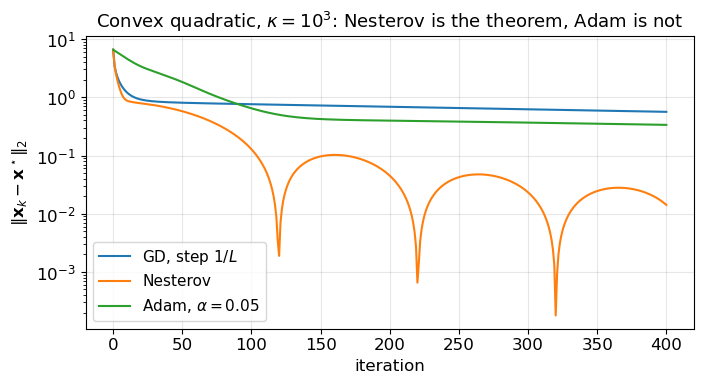

In [6]:
d, kappa, n_iter = 40, 1e3, 400
eigs = np.linspace(1.0, kappa, d)
Q, _ = np.linalg.qr(rng.normal(size=(d, d)))
H = Q @ np.diag(eigs) @ Q.T
x_star = rng.normal(size=d)
L_smooth = eigs[-1]
eta = 1.0 / L_smooth


def err(x):
    return np.linalg.norm(x - x_star)


# Gradient descent.
x = np.zeros(d)
hist_gd = [err(x)]
for _ in range(n_iter):
    x = x - eta * (H @ (x - x_star))
    hist_gd.append(err(x))

# Nesterov accelerated gradient (one standard form).
x = np.zeros(d)
x_prev = x.copy()
hist_nes = [err(x)]
for k in range(n_iter):
    beta = k / (k + 3)
    y = x + beta * (x - x_prev)
    x_prev = x
    x = y - eta * (H @ (y - x_star))
    hist_nes.append(err(x))

# Adam — same budget, a typical deep-learning step size.
x = np.zeros(d)
m = np.zeros(d)
v = np.zeros(d)
beta1, beta2, eps_adam, alpha = 0.9, 0.999, 1e-8, 0.05
hist_adam = [err(x)]
for t in range(1, n_iter + 1):
    g = H @ (x - x_star)
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * (g * g)
    mhat = m / (1 - beta1**t)
    vhat = v / (1 - beta2**t)
    x = x - alpha * mhat / (np.sqrt(vhat) + eps_adam)
    hist_adam.append(err(x))

print(f"condition number = {kappa:.0e},  step 1/L = {eta:.3e}")
print(f"after {n_iter} steps:  GD {hist_gd[-1]:.3e}   Nesterov {hist_nes[-1]:.3e}   Adam {hist_adam[-1]:.3e}")

fig, ax = plt.subplots()
ax.semilogy(hist_gd, label="GD, step $1/L$")
ax.semilogy(hist_nes, label="Nesterov")
ax.semilogy(hist_adam, label="Adam, $\\alpha=0.05$")
ax.set_xlabel("iteration")
ax.set_ylabel(r"$\|\mathbf{x}_k - \mathbf{x}^\star\|_2$")
ax.set_title(r"Convex quadratic, $\kappa=10^3$: Nesterov is the theorem, Adam is not")
ax.legend()
fig.tight_layout()
plt.show()


### Takeaway

- Complexity is a theorem about *worst-case* smooth convex problems.
- Deep-learning training is not that setting (interpolation, overparametrization, noise).
- The course will keep these two sentences apart: what we can prove for GD/Nesterov, and what Adam empirically does.

### References — acceleration, lower bounds, Adam

- **Paper (the $O(1/k^2)$ method).** Y. Nesterov, [*A method of solving a convex programming problem with convergence rate $O(1/k^2)$*](https://www.mathnet.ru/eng/dan/v269/i3/p543), *Dokl. Akad. Nauk SSSR* 1983.
- **Lower bounds.** A. Nemirovski and D. Yudin, *Problem Complexity and Method Efficiency in Optimization* (Wiley, 1983); modern write-up in Bubeck’s [survey](https://arxiv.org/abs/1405.4980), Ch. 3–4, and Nesterov’s 2018 lectures, Ch. 2.
- **Survey.** A. d'Aspremont, D. Scieur, A. Taylor, [*Acceleration methods*](https://arxiv.org/abs/2101.09545), *Found. Trends Opt.* 2021.
- **Adam, and why it is not Nesterov.** D. Kingma and J. Ba, [*Adam*](https://arxiv.org/abs/1412.6980), ICLR 2015; S. Reddi, S. Kale, S. Kumar, [*On the convergence of Adam and beyond*](https://arxiv.org/abs/1904.09237), ICLR 2018; A. Défossez et al., [*A simple convergence proof of Adam and Adagrad*](https://arxiv.org/abs/2003.02395), *TMLR* 2022.
- **Tutorial.** L. Bottou, F. Curtis, J. Nocedal, [*Optimization methods for large-scale machine learning*](https://arxiv.org/abs/1606.04838), *SIAM Review* 2018.